# ARIMA 3 - SARIMA, ARIMAX, SARIMAX
- Revisão
- Treinar identificação de AR e MA
- Modelos incompletos
- Modelos Sazonais
- Utlizando variáveis exógenas
- SARIMAX

In [1]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
plt.rcParams["figure.figsize"] = [12, 5]

def all_ac(Y, lags = 15):
    fig, ax = plt.subplots(1, 2, figsize=(16,5))
    plot_acf(Y, zero=False, ax=ax[0], lags=lags)
    ax[0].set_title('ACF')
    plot_pacf(Y, zero=False, ax=ax[1],lags=lags)
    ax[1].set_title('PACF')
    plt.show()

def plot_forecast(serie_original, previsao):
    plt.plot(serie_original, label='Serie Histórica', linestyle='-')  
    plt.plot(previsao, label='Previsão', linestyle='--')  
    plt.xlabel('Data')
    plt.ylabel('Valores')
    plt.title('Serie histórica com previsão')
    plt.legend()
    plt.show()
    
def teste_estacionariedade(s):
    warnings.simplefilter("ignore", category=UserWarning)
    kps = kpss(s)
    adf = adfuller(s)
    warnings.simplefilter("default", category=UserWarning)
    kpss_pv, adf_pv = kps[1], adf[1]
    kpssh, adfh = 'Estacionário', 'Não Estacionário'
    if adf_pv < 0.05:
        adfh = 'Estacionário'
    if kpss_pv < 0.05:
        kpssh = 'Não Estacionário'
    return (kpssh, adfh)

## Último modelo que fizemos

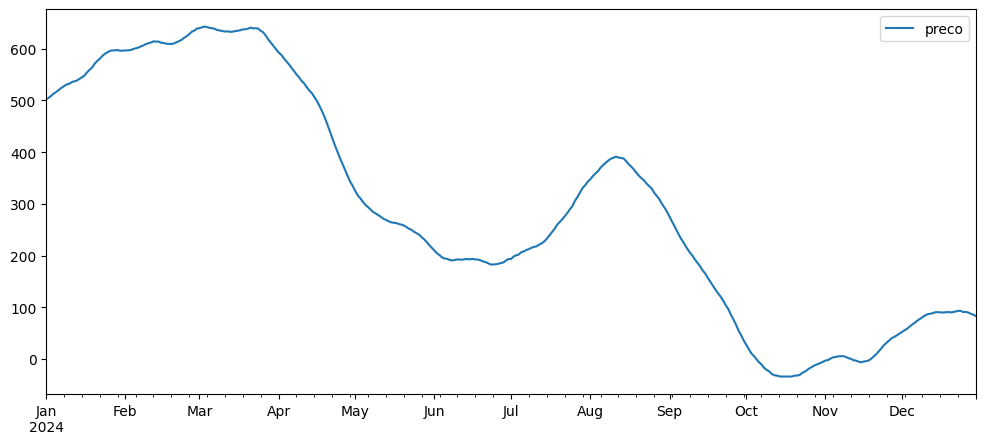

In [2]:
Y = pd.read_csv('/Users/danielferreira/Documents/git/classes/ASN/Séries Temporais/dados/ARIMA_Exemplo.csv')
Y.index = pd.date_range(start='2024-01-01', periods = 365)
Y.plot()
plt.show()

In [3]:
teste_estacionariedade(Y)

('Não Estacionário', 'Não Estacionário')

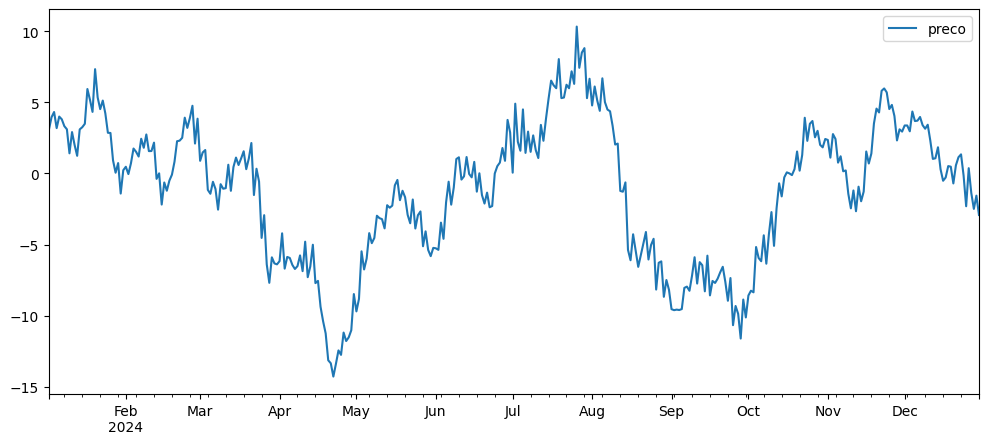

('Estacionário', 'Estacionário')

In [4]:
primeira_ordem = Y.diff().dropna()
primeira_ordem.plot()
plt.show()
teste_estacionariedade(primeira_ordem)

In [5]:
def diagnostico(model, lags = 15):
    print(model.summary())
    model.plot_diagnostics()
    plt.show()
    residuo = model.resid
    residuo = residuo[1:] 
    all_ac(residuo, lags = lags)
    plt.show()

                               SARIMAX Results                                
Dep. Variable:                  preco   No. Observations:                  365
Model:                 ARIMA(2, 1, 3)   Log Likelihood                -514.589
Date:                Wed, 05 Mar 2025   AIC                           1041.178
Time:                        10:24:30   BIC                           1064.561
Sample:                    01-01-2024   HQIC                          1050.472
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5211      0.053      9.863      0.000       0.418       0.625
ar.L2          0.4295      0.054      7.886      0.000       0.323       0.536
ma.L1         -0.0321      0.025     -1.286      0.1

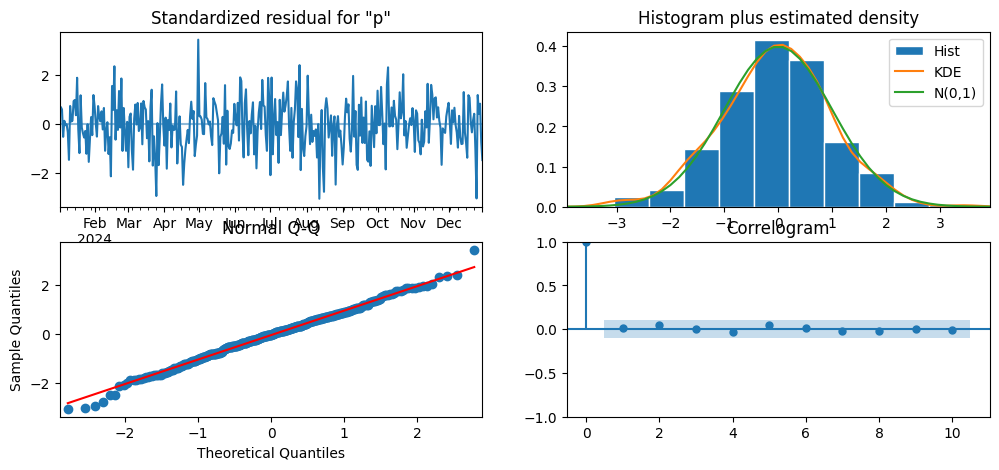

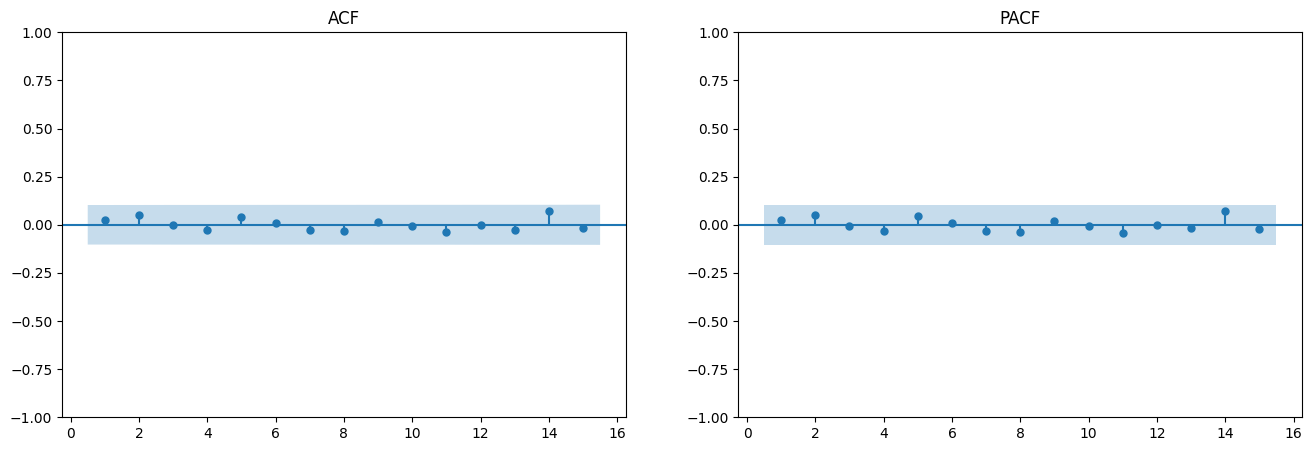

In [6]:
model = ARIMA(Y, order=(2, 1, 3)).fit()
diagnostico(model)

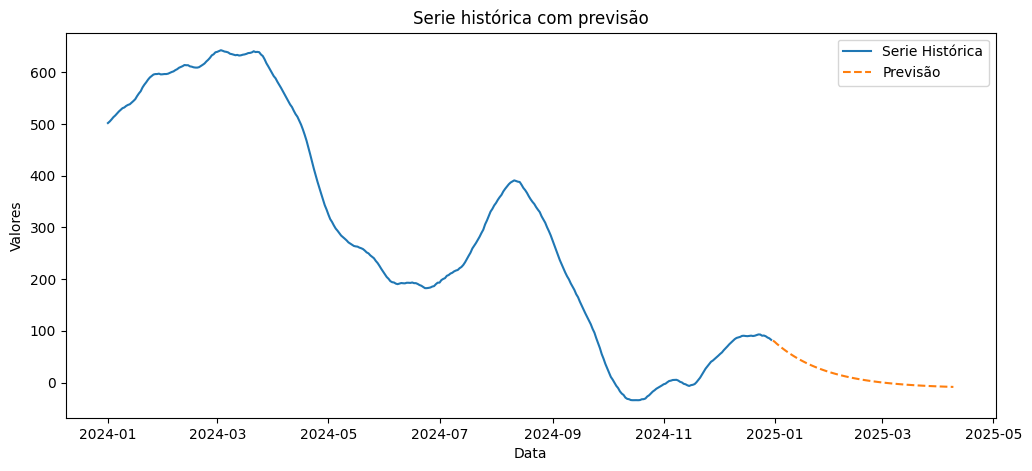

In [7]:
previsao = model.forecast(100)
plot_forecast(Y,previsao)

## Modelos incompletos

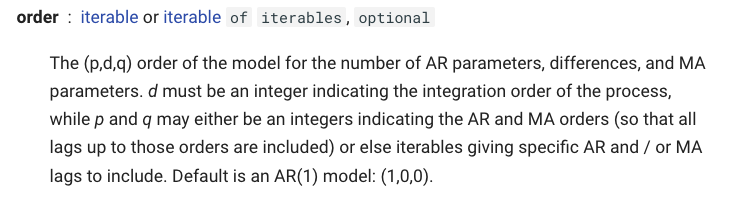

                               SARIMAX Results                                
Dep. Variable:                  preco   No. Observations:                  365
Model:               ARIMA(2, 1, [3])   Log Likelihood                -515.275
Date:                Wed, 05 Mar 2025   AIC                           1038.549
Time:                        10:24:31   BIC                           1054.138
Sample:                    01-01-2024   HQIC                          1044.745
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4931      0.047     10.540      0.000       0.401       0.585
ar.L2          0.4567      0.048      9.528      0.000       0.363       0.551
ma.L3          0.9217      0.023     39.346      0.0

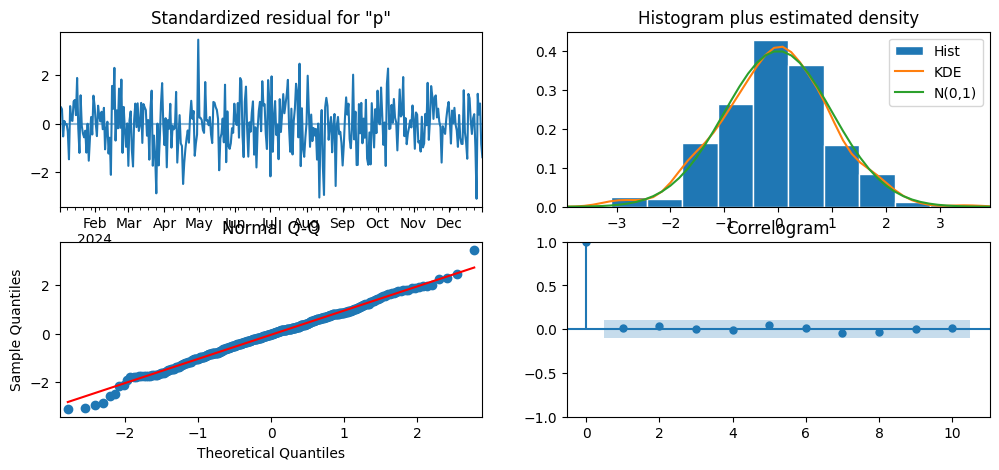

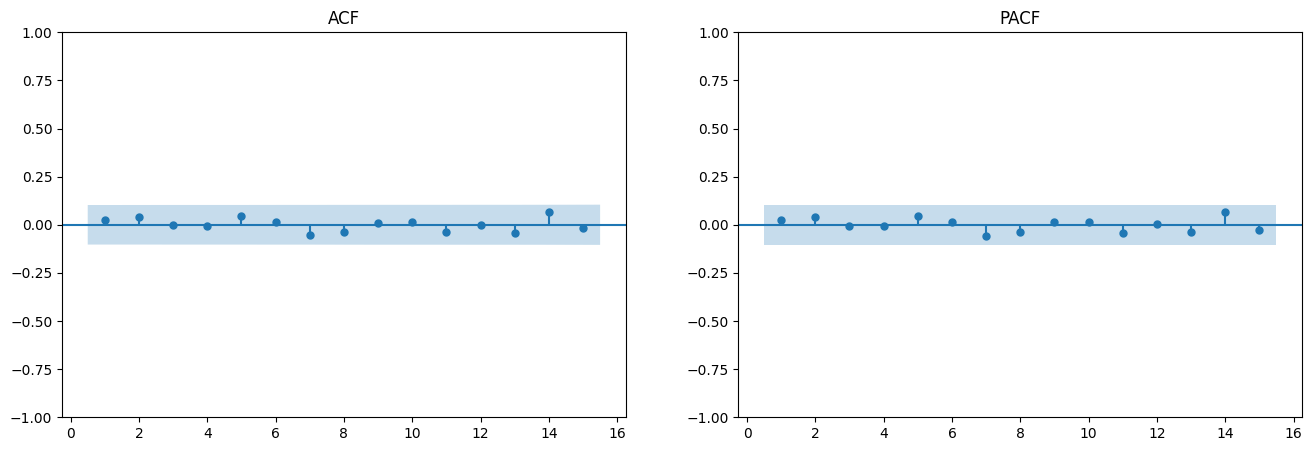

In [8]:
model = ARIMA(Y, order=(2, 1, (0,0,1))).fit()
diagnostico(model)

Reparem que o BIC e o AIC estão menores

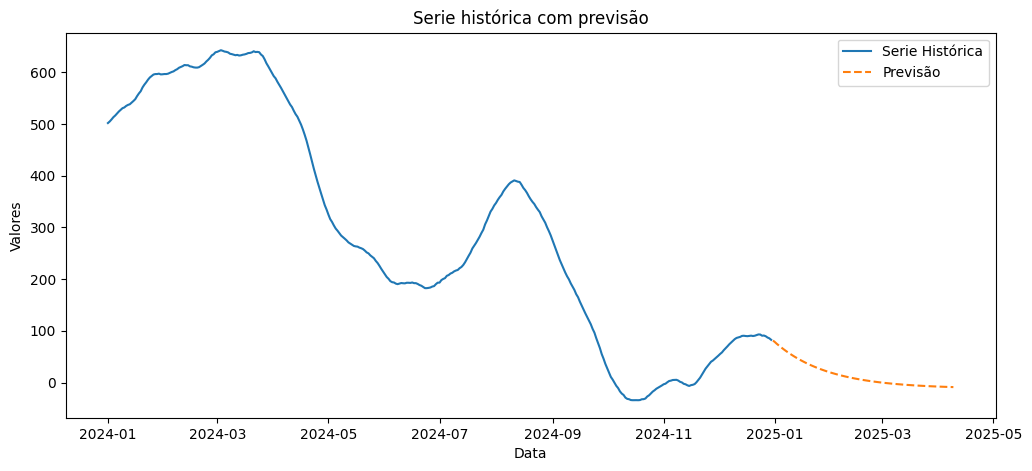

In [9]:
previsao = model.forecast(100)
plot_forecast(Y,previsao)

ARIMA(2,1,(0,0,1))
$$ \large (1 - B) Y_t = \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \theta_3 \epsilon_{t-3} + \epsilon_t $$

$$ \large (1 - B) Y_t = 0.493 Y_{t-1} + 0.457 Y_{t-2} + 0.922 \epsilon_{t-3} + \epsilon_t $$

In [10]:
model.params

ar.L1     0.493122
ar.L2     0.456669
ma.L3     0.921652
sigma2    0.969362
dtype: float64

## Treinando identificação de séries

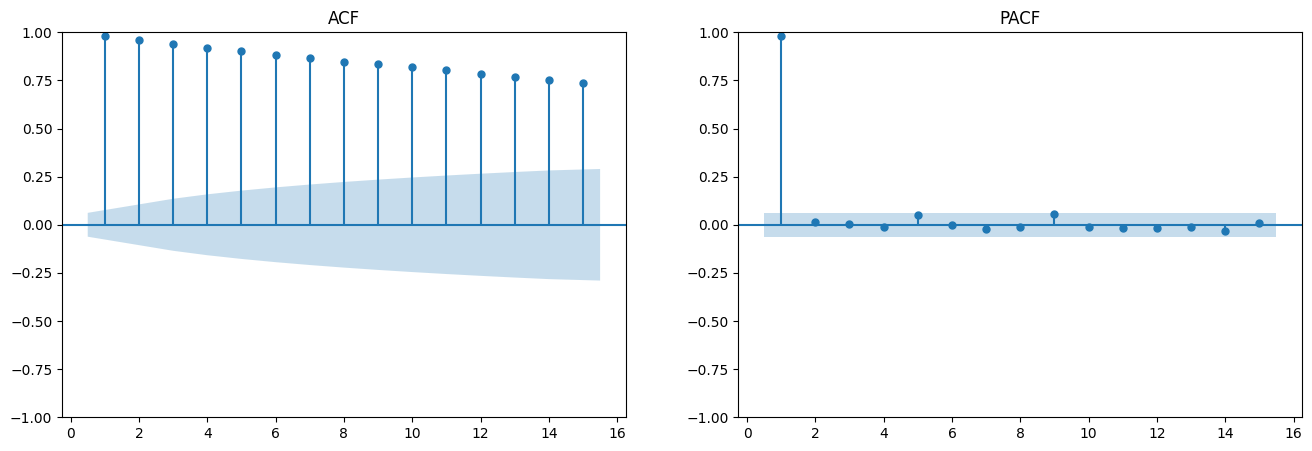

In [11]:
import geracao_de_series as gc
np.random.seed(42)
Y = pd.Series(gc.generate_ar_series([0.98], n_samples=1000))
all_ac(Y)

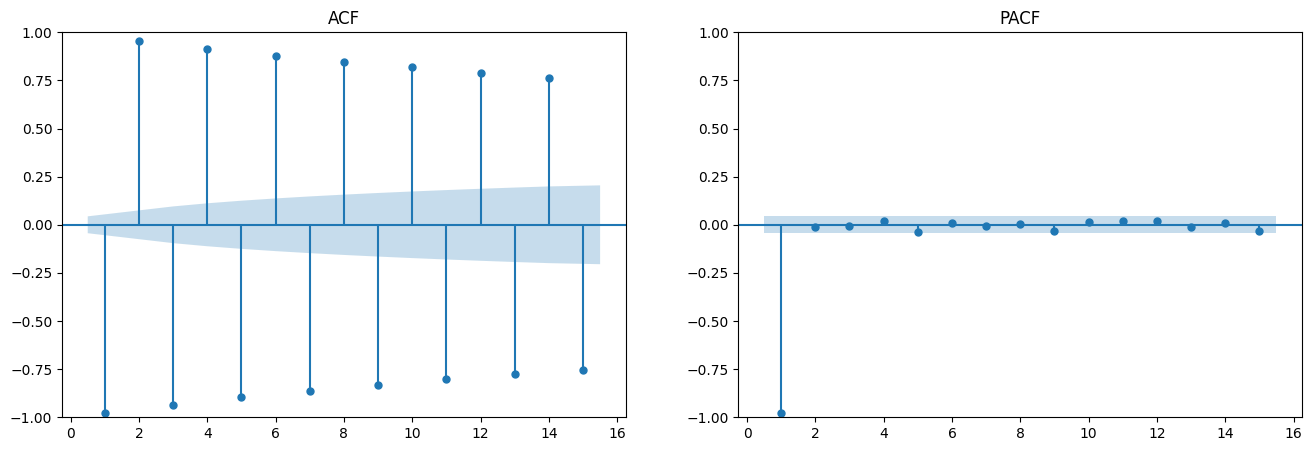

In [12]:
np.random.seed(42)
Y = pd.Series(gc.generate_ar_series([-0.98]))
all_ac(Y)

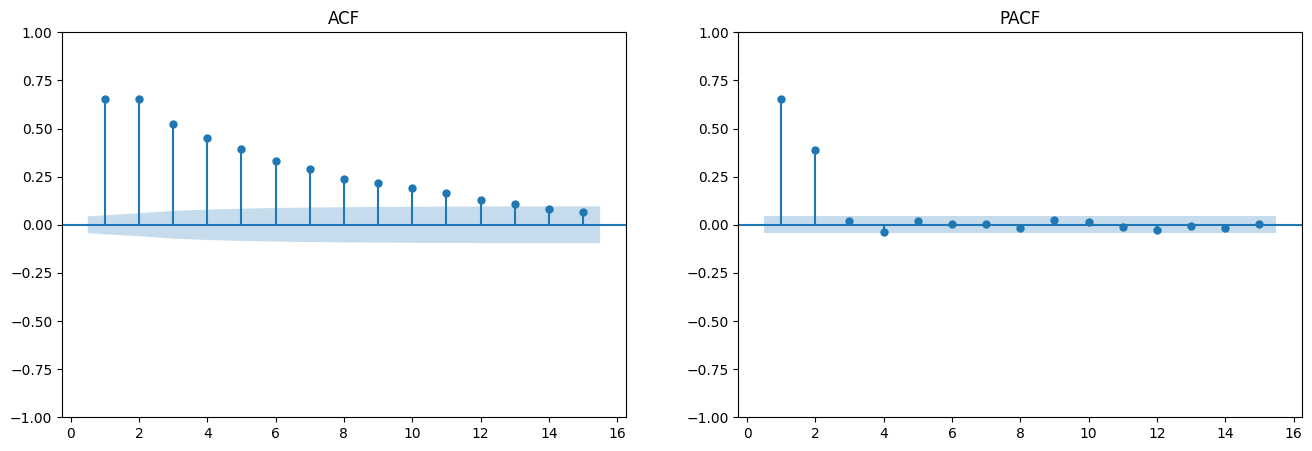

In [13]:
np.random.seed(42)
Y = pd.Series(gc.generate_ar_series([0.4, 0.4]))
all_ac(Y)

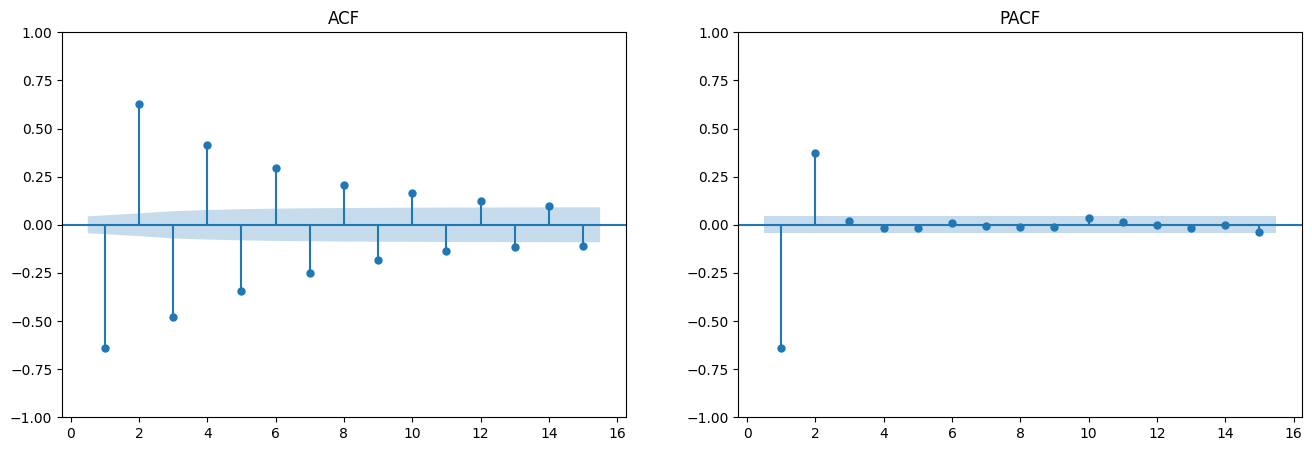

In [14]:
np.random.seed(42)
Y = pd.Series(gc.generate_ar_series([-0.4, 0.4]))
all_ac(Y)

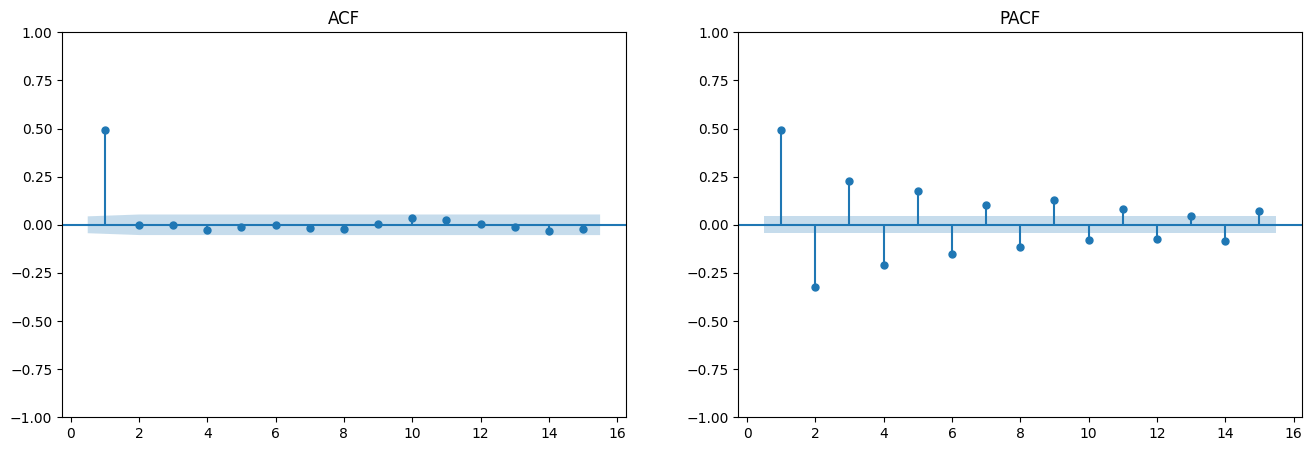

In [15]:
np.random.seed(42)
Y = pd.Series(gc.generate_ma_series([0.98]))
all_ac(Y)

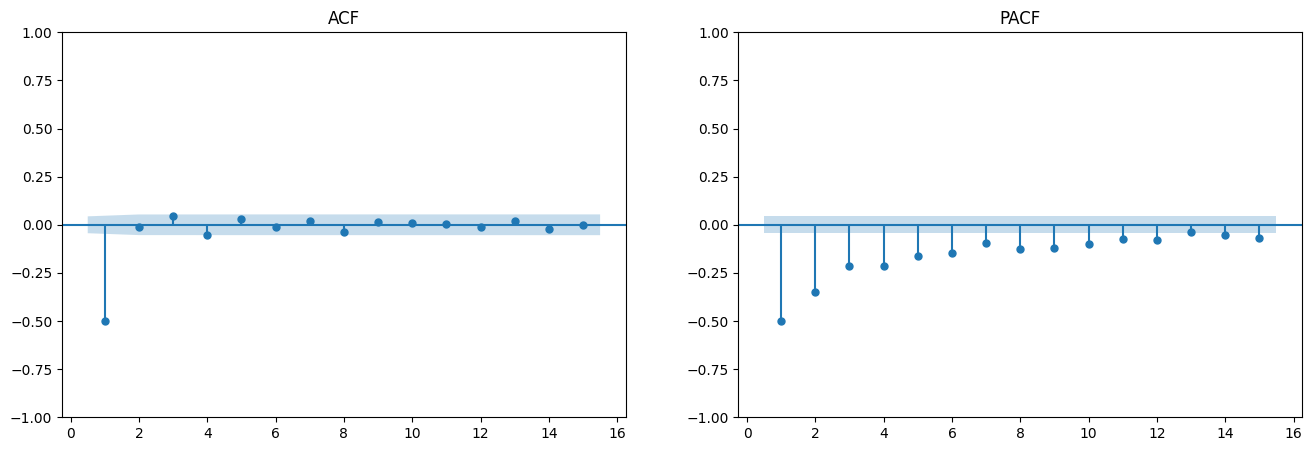

In [16]:
np.random.seed(42)
Y = pd.Series(gc.generate_ma_series([-0.98]))
all_ac(Y)

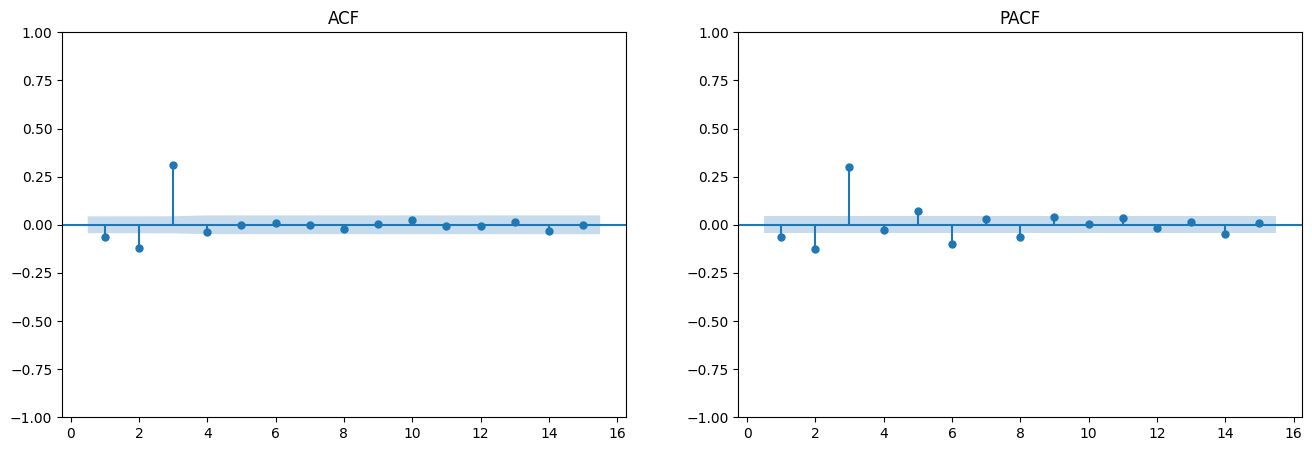

In [17]:
np.random.seed(42)
Y = pd.Series(gc.generate_ma_series([-0.4, -0,3]))
all_ac(Y)

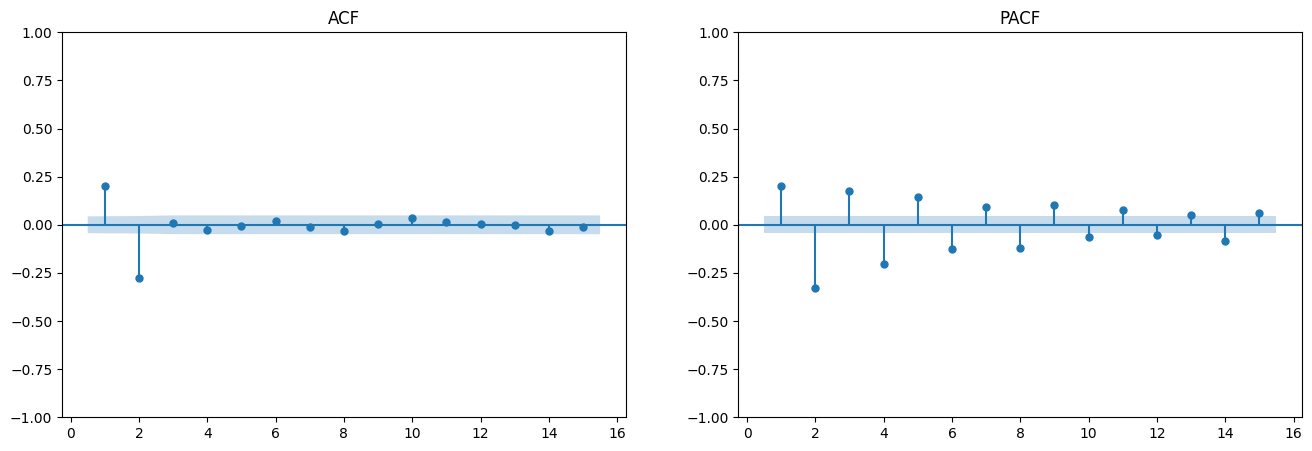

In [18]:
np.random.seed(42)
Y = pd.Series(gc.generate_ma_series([0.5,-0.4]))
all_ac(Y)

## SARIMA

$$
\large (1 - B)^d (1 - B^s)^D Y_t = c + \phi_1 Y_{t-1} + \dots + \phi_p Y_{t-p} + \Phi_1 Y_{t-s} + \dots + \Phi_P Y_{t-Ps} + \epsilon_t + \theta_1 \epsilon_{t-1} + \dots + \theta_q \epsilon_{t-q} + \Theta_1 \epsilon_{t-s} + \dots + \Theta_Q \epsilon_{t-Qs}
$$

### SARIMA (1,0,1)(1,0,1)_12
$$
\large (1 - \phi_1 B)(1 - \Phi_1 B^{12}) Y_t = c + (1 + \theta_1 B)(1 + \Theta_1 B^{12}) \epsilon_t
$$

$$
\large Y_t = c + \phi_1 Y_{t-1} + \Phi_1 Y_{t-12} - \phi_1 \Phi_1 Y_{t-13} + \epsilon_t + \theta_1 \epsilon_{t-1} + \Theta_1 \epsilon_{t-12} + \theta_1 \Theta_1 \epsilon_{t-13}
$$


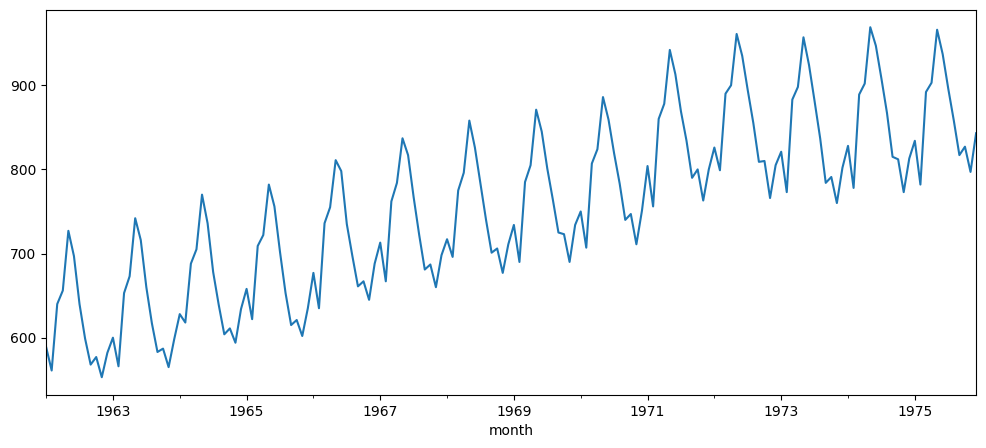

In [19]:
milk = pd.read_csv('/Users/danielferreira/Documents/git/classes/ASN/Séries Temporais/dados/milk_production.csv')
milk.index = pd.to_datetime(milk['month'])
milk.index.freq = 'MS'
milk_prod = pd.Series(milk['production'], name="produção de leite")
milk_prod.plot()
plt.show()

In [20]:
teste_estacionariedade(milk_prod)

('Não Estacionário', 'Não Estacionário')

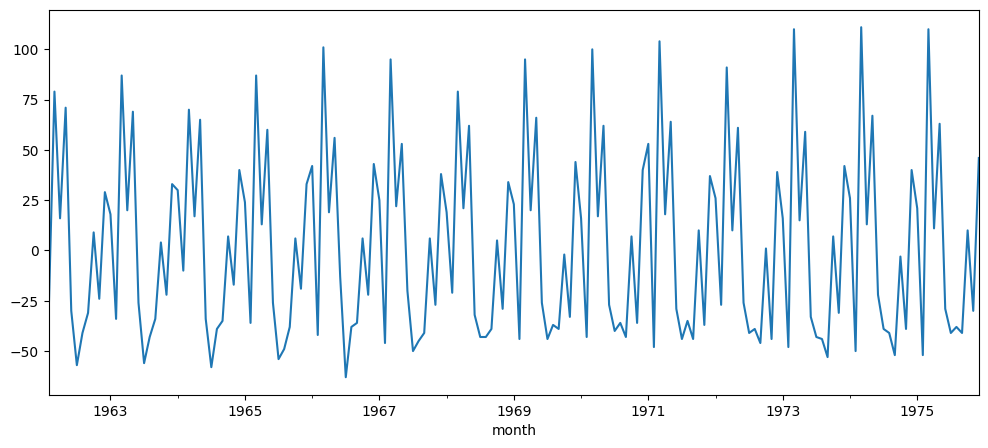

('Estacionário', 'Estacionário')

In [21]:
primeira_ordem = milk_prod.diff().dropna()
primeira_ordem.plot()
plt.show()
teste_estacionariedade(primeira_ordem)

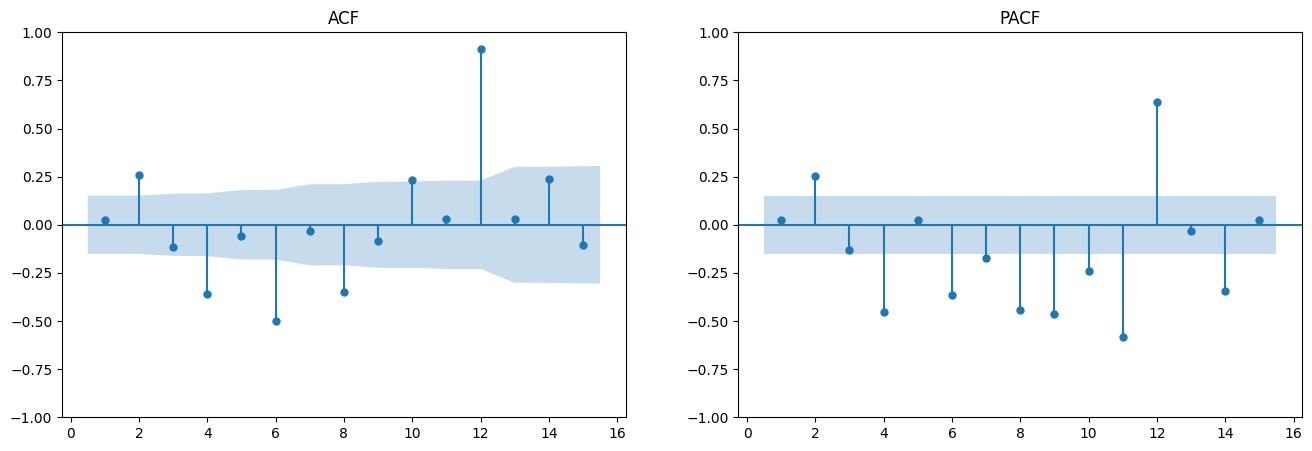

In [22]:
all_ac(primeira_ordem)

                               SARIMAX Results                                
Dep. Variable:      produção de leite   No. Observations:                  168
Model:               ARIMA(0, 1, [2])   Log Likelihood                -861.689
Date:                Wed, 05 Mar 2025   AIC                           1727.378
Time:                        10:24:33   BIC                           1733.614
Sample:                    01-01-1962   HQIC                          1729.909
                         - 12-01-1975                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L2          0.4300      0.077      5.557      0.000       0.278       0.582
sigma2      1771.2201    260.113      6.809      0.000    1261.408    2281.032
Ljung-Box (L1) (Q):                   0.39   Jarque-

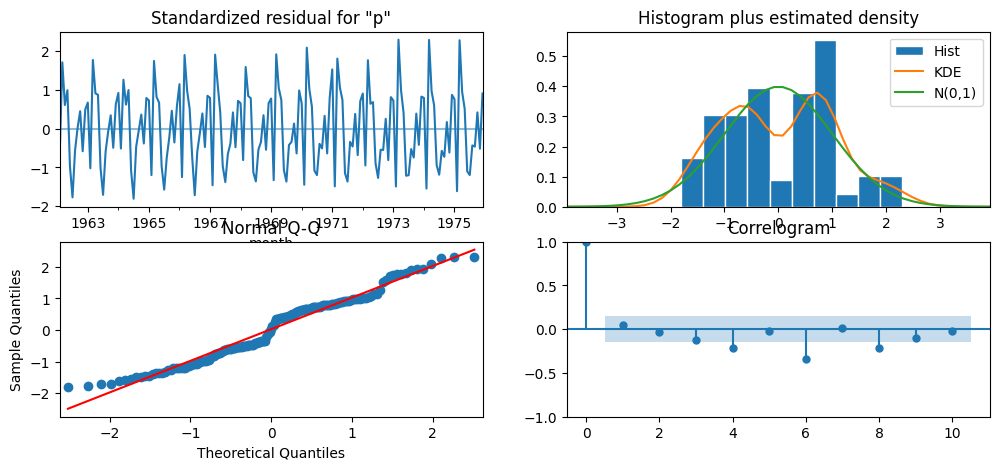

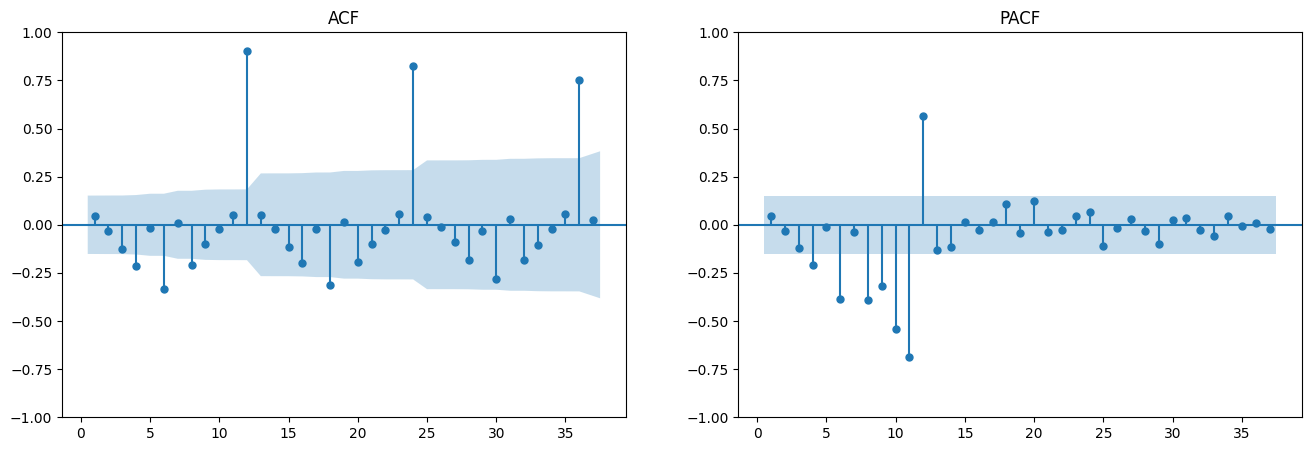

In [23]:
model = ARIMA(milk_prod, order = (0,1,(0,1))).fit()
diagnostico(model, lags=37)

                               SARIMAX Results                                
Dep. Variable:      produção de leite   No. Observations:                  168
Model:              ARIMA([12], 1, 0)   Log Likelihood                -620.981
Date:                Wed, 05 Mar 2025   AIC                           1245.963
Time:                        10:28:47   BIC                           1252.199
Sample:                    01-01-1962   HQIC                          1248.494
                         - 12-01-1975                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L12         0.9806      0.009    104.684      0.000       0.962       0.999
sigma2        78.6520      5.951     13.216      0.000      66.988      90.316
Ljung-Box (L1) (Q):                   6.61   Jarque-

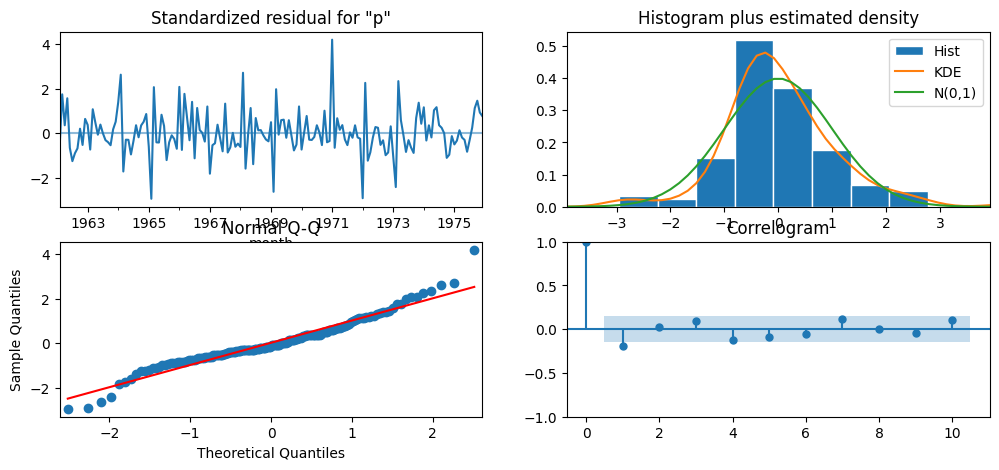

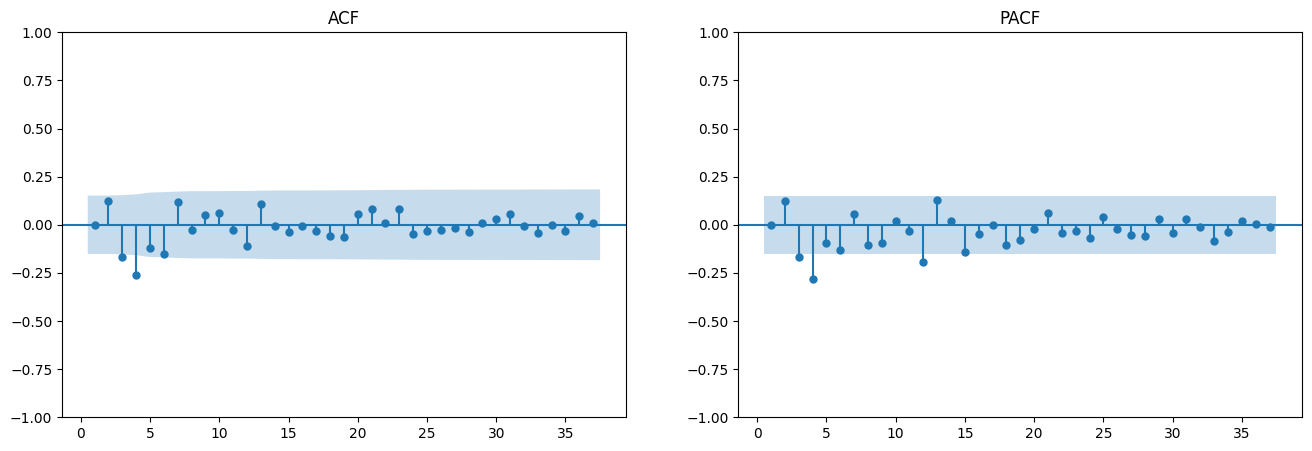

In [30]:
model = ARIMA(milk_prod, order = ((0,0,0,0,0,0,0,0,0,0,0,1),1,0), freq='MS').fit()
diagnostico(model, lags=37)

$$
\large (1 -  B) Y_t =  \phi_{12} Y_{t-12} + \epsilon_t
$$

$$
\large (1 -  B) Y_t =  0.9806 Y_{t-12} + \epsilon_t
$$

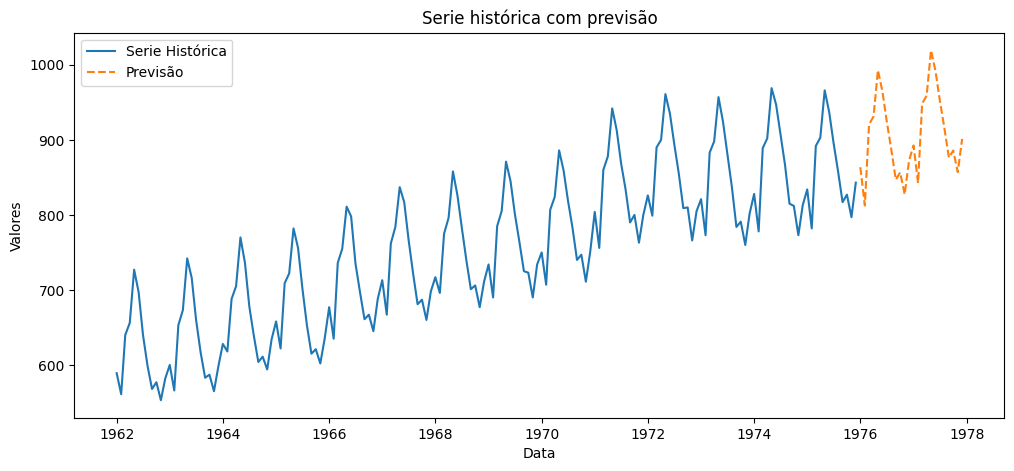

In [31]:
previsao = model.forecast(24)
plot_forecast(milk_prod,previsao)

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.21474D+00    |proj g|=  2.32209D-02

At iterate    5    f=  3.20118D+00    |proj g|=  1.39404D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3      8     12      1     0     0   6.737D-06   3.201D+00
  F =   3.2011419010093518     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
                                     SARIMAX Results                                      
Dep. Variable:                  produção 

 This problem is unconstrained.


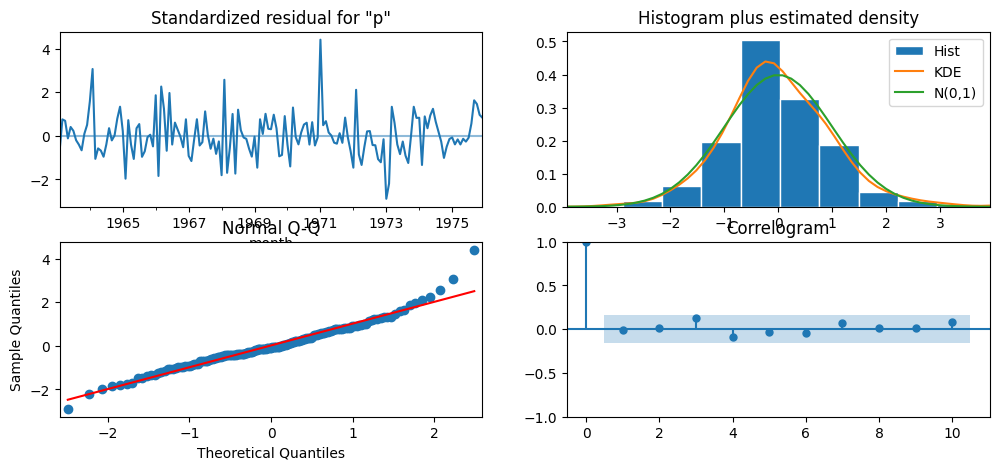

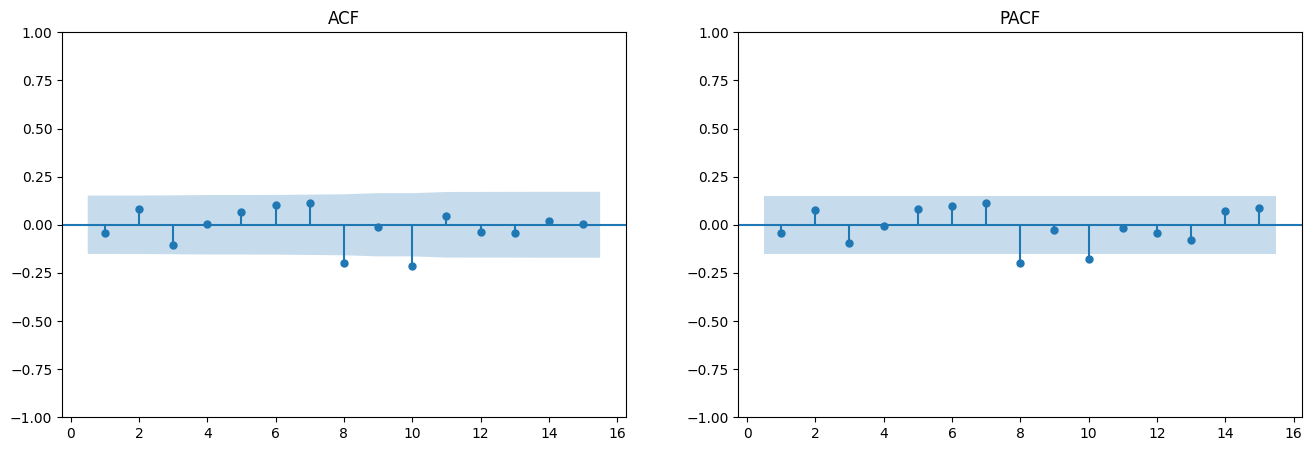

In [34]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(milk_prod, order = (1,1,0), seasonal_order=(1,1,0,12)).fit()
diagnostico(model)

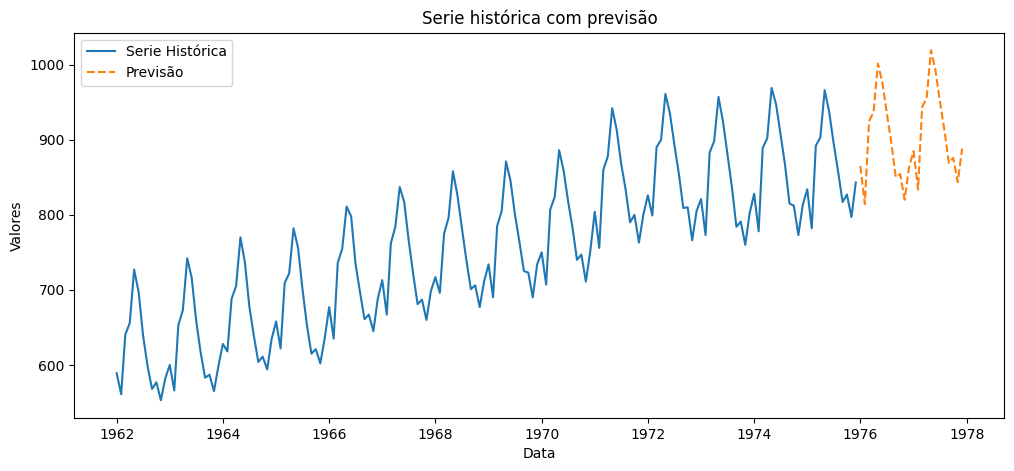

In [35]:
previsao = model.forecast(24)
plot_forecast(milk_prod,previsao)

In [26]:
milk

,month,production
month,,
1962-01-01,1962-01-01,589
1962-02-01,1962-02-01,561
1962-03-01,1962-03-01,640
1962-04-01,1962-04-01,656
1962-05-01,1962-05-01,727
...,...,...
1975-08-01,1975-08-01,858
1975-09-01,1975-09-01,817
1975-10-01,1975-10-01,827


<Axes: xlabel='month'>

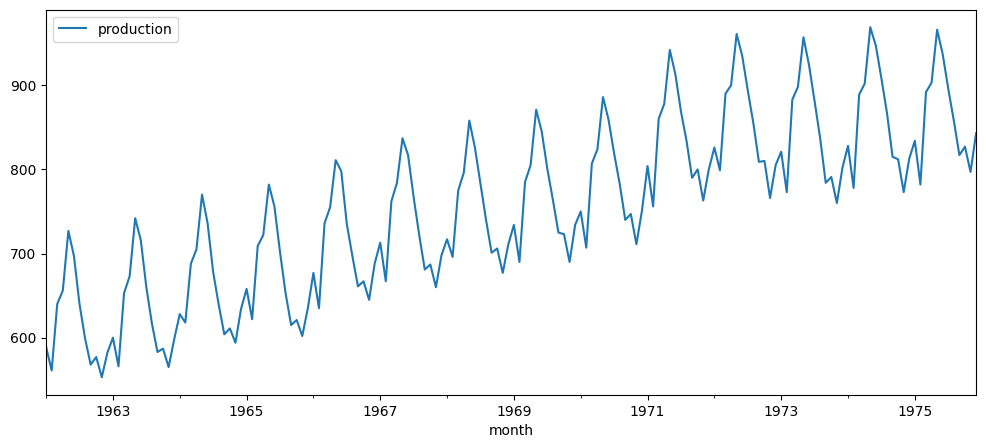

In [27]:
milk.plot()